# **딥러닝-회귀**


## **1.환경준비**

### (1) 라이브러리 Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [ ]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [ ]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 연결

        # Feed Forward
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [ ]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [ ]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [ ]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### (4) 데이터로딩

In [ ]:
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/boston.csv'
data = pd.read_csv(path)
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


|	변수	|	설명	|
|	----	|	----	|
|	medv	|	타운별 집값(중위수)	|
|	crim	|	범죄율	|
|	zn	|	25,000 평방피트를 초과 거주지역 비율	|
|	indus	|	비소매상업지역 면적 비율	|
|	chas	|	찰스강변 위치(범주 : 강변1, 아니면 0)	|
|	nox	|	일산화질소 농도	|
|	rm	|	주택당 방 수	|
|	age	|	1940년 이전에 건축된 주택의 비율	|
|	dis	|	직업센터의 거리	|
|	rad	|	방사형 고속도로까지의 거리	|
|	tax	|	재산세율	|
|	ptratio	|	학생/교사 비율	|
|	lstat	|	인구 중 하위 계층 비율	|


## **2.데이터 준비**

lstat, ptratio, crim 만 이용하여 medv를 예측하는 모델을 만들어 봅시다.

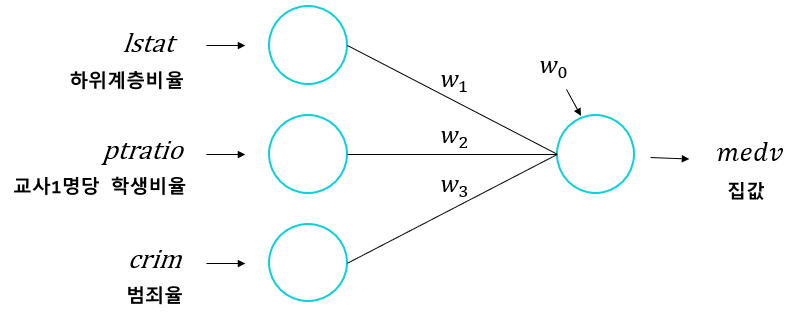

### (1) 데이터 준비
* x, y 나누기
    * x : lstat, ptratio, crim
    * y : medv

In [ ]:
target = 'medv'
features = ['lstat', 'ptratio', 'crim']
x = data.loc[:, features]
y = data.loc[:, target]

### (2) 가변수화

### (3) 데이터분할

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)

### (4) Scaling

In [ ]:
# 스케일러 선언
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## **3.모델링1 : feature 3개**

### (1) 딥러닝을 위한 준비작업

* make_DataLoader
    * train : 미니 배치 처리를 위한 데이터 로더로 만들기
    * val : 검증셋으로 성능 측정하면 되므로 텐서 그대로 사용

In [ ]:
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [ ]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f"Shape of x [rows, columns]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [rows, columns]: torch.Size([32, 3])
Shape of y: torch.Size([32, 1]) torch.float32


### (2) 모델 선언

* nn.Linear(입력, 출력) 레이어 한개를 추가해 봅시다.
    * [출력] 층의 **노드 수** 입니다.

In [ ]:
x.shape[1]

3

In [ ]:
n_feature = x.shape[1]

# 모델 구조 설계
model1 = nn.Sequential(
        nn.Linear(n_feature, 1)
        ).to(device)

print(model1)

Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
)


* Loss function과 Optimizer
    * loss function : MSE
    * Optimizer : Adam(모델 파라미터, 학습률)

In [ ]:
loss_fn = nn.MSELoss()
optimizer = Adam(model1.parameters(), lr=0.01)

### (3) 학습

In [ ]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 573.461426, val loss : 494.047058
Epoch 2, train loss : 561.999146, val loss : 484.009674
Epoch 3, train loss : 548.128418, val loss : 474.176636
Epoch 4, train loss : 544.019104, val loss : 464.601562
Epoch 5, train loss : 531.060303, val loss : 455.135223
Epoch 6, train loss : 524.624756, val loss : 445.905334
Epoch 7, train loss : 516.722534, val loss : 436.831024
Epoch 8, train loss : 505.919312, val loss : 427.889923
Epoch 9, train loss : 498.638550, val loss : 419.241913
Epoch 10, train loss : 490.916138, val loss : 410.731812
Epoch 11, train loss : 477.750610, val loss : 402.378326
Epoch 12, train loss : 473.234985, val loss : 394.228088
Epoch 13, train loss : 460.861603, val loss : 386.271515
Epoch 14, train loss : 450.605621, val loss : 378.533356
Epoch 15, train loss : 448.993103, val loss : 370.913574
Epoch 16, train loss : 440.007538, val loss : 363.402985
Epoch 17, train loss : 433.116516, val loss : 356.098419
Epoch 18, train loss : 419.706909, val l

* 학습된 파라미터 확인

In [ ]:
for name, param in model1.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[4.9016, 5.7675, 4.0026]])
Parameter: 0.bias, Value: tensor([6.0355])


In [ ]:
# ['lstat', 'ptratio', 'crim']

* 학습 곡선

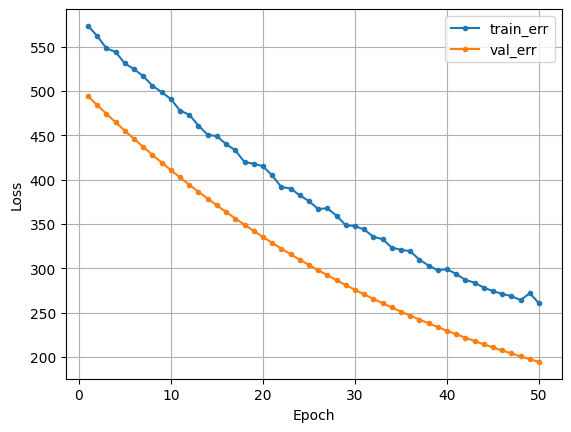

In [ ]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (4) 모델 평가

In [ ]:
loss, pred = evaluate(x_val_ts, y_val_ts, model1, loss_fn, device)
print(f'MSE : {loss}')

MSE : 194.2178955078125


* 평가 추가 : MAE, MAPE

In [ ]:
mae = mean_absolute_error(y_val_ts.numpy(), pred.numpy())
mape = mean_absolute_percentage_error(y_val_ts.numpy(), pred.numpy())
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MAE : 11.113059043884277
MAPE : 0.48213469982147217


## **4.모델링2 : feature 전체**
* 이제 전체 데이터를 가지고 모델링을 시도해 보겠습니다.


### (1) 데이터 전처리

* 데이터 분할

In [ ]:
target = 'medv'
x = data.drop(target, axis = 1)
y = data.loc[:, target]
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)

* 스케일링

In [ ]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

### (2) 모델링

* make_DataLoader

In [ ]:
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val)

* 모델 설계

In [ ]:
n_feature = x.shape[1]

# 모델 구조 설계
model2 = nn.Sequential(
          nn.Linear(n_feature, 1)
                       ).to(device)

print(model2)

Sequential(
  (0): Linear(in_features=12, out_features=1, bias=True)
)


* Loss function과 Optimizer

In [ ]:
loss_fn = nn.MSELoss()
optimizer = Adam(model2.parameters(), lr=0.01)

### (3) 학습

In [ ]:
epochs = 50
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 591.104614, val loss : 497.892670
Epoch 2, train loss : 562.759216, val loss : 472.811890
Epoch 3, train loss : 530.352844, val loss : 448.843292
Epoch 4, train loss : 506.883942, val loss : 426.391998
Epoch 5, train loss : 484.093445, val loss : 405.050018
Epoch 6, train loss : 466.838928, val loss : 385.045532
Epoch 7, train loss : 438.118927, val loss : 365.914398
Epoch 8, train loss : 424.370636, val loss : 347.914459
Epoch 9, train loss : 403.037262, val loss : 331.057343
Epoch 10, train loss : 387.370819, val loss : 315.252350
Epoch 11, train loss : 368.007965, val loss : 300.472992
Epoch 12, train loss : 352.668243, val loss : 286.398865
Epoch 13, train loss : 340.574524, val loss : 273.568237
Epoch 14, train loss : 322.273010, val loss : 261.495605
Epoch 15, train loss : 311.553253, val loss : 250.138504
Epoch 16, train loss : 297.988708, val loss : 239.455276
Epoch 17, train loss : 284.726135, val loss : 229.543640
Epoch 18, train loss : 279.891907, val l

* 학습된 파라미터 확인

In [ ]:
for name, param in model2.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-1.7839,  4.7945,  3.1799,  3.9622,  3.1283,  4.4657,  3.3979,  4.6335,
          2.3224,  2.7661,  3.8600,  2.2110]])
Parameter: 0.bias, Value: tensor([4.5331])


* 학습 곡선

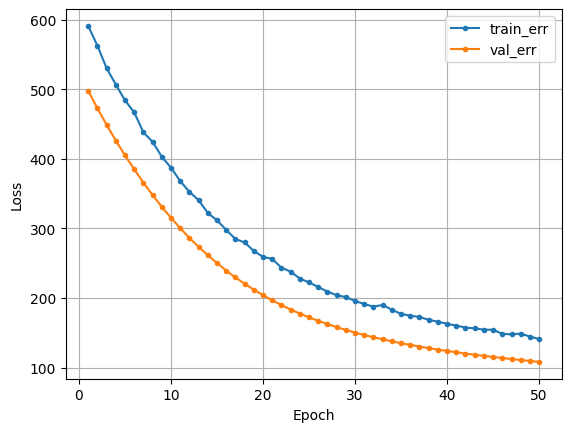

In [ ]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (4) 모델 평가

In [ ]:
loss, pred = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)

mae = mean_absolute_error(y_val_ts.numpy(), pred.numpy())
mape = mean_absolute_percentage_error(y_val_ts.numpy(), pred.numpy())

print(f'MSE : {loss}')
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MSE : 108.1407699584961
MAE : 7.630967140197754
MAPE : 0.3924303948879242


## **5.모델링3 : 은닉층 추가**

### (1) 데이터 전처리
4.모델링2 에서 준비한 데이터를 이용합니다.

### (2) 모델링
4.모델링2 에서 선언한 DataLoader를 그대로 사용합니다.

* 모델 설계

In [ ]:
n_feature = x.shape[1]

# 모델 구조 설계
model3 = nn.Sequential(
            nn.Linear(n_feature, 2),
            nn.ReLU(),
            nn.Linear(2, 1),
        ).to(device)

print(model3)

Sequential(
  (0): Linear(in_features=12, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
)


* Loss function과 Optimizer

In [ ]:
loss_fn = nn.MSELoss()
optimizer = Adam(model3.parameters(), lr=0.01)

### (3) 학습

In [ ]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model3, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 575.665466, val loss : 483.031708
Epoch 2, train loss : 529.208862, val loss : 427.190918
Epoch 3, train loss : 460.471069, val loss : 359.998047
Epoch 4, train loss : 390.679413, val loss : 287.776154
Epoch 5, train loss : 310.930573, val loss : 221.114777
Epoch 6, train loss : 250.984039, val loss : 169.880646
Epoch 7, train loss : 200.262268, val loss : 137.058578
Epoch 8, train loss : 169.172043, val loss : 121.237244
Epoch 9, train loss : 153.760559, val loss : 112.879044
Epoch 10, train loss : 143.759827, val loss : 106.286545
Epoch 11, train loss : 133.329208, val loss : 99.689873
Epoch 12, train loss : 125.333969, val loss : 93.265938
Epoch 13, train loss : 120.036003, val loss : 87.685310
Epoch 14, train loss : 112.759773, val loss : 81.947449
Epoch 15, train loss : 104.462334, val loss : 76.714371
Epoch 16, train loss : 98.066109, val loss : 71.656937
Epoch 17, train loss : 92.112183, val loss : 67.379356
Epoch 18, train loss : 86.967201, val loss : 63.4

* 학습된 파라미터 확인

In [ ]:
for name, param in model3.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-1.1207,  0.2361,  0.4723,  0.4337, -0.0388,  3.8871,  1.1229, -0.2398,
          0.7292, -0.2593, -0.6678, -3.5327],
        [-1.9791,  0.7595, -0.3984,  0.6940, -0.6800,  3.5652,  0.6806, -0.3773,
          0.0716, -0.9887, -0.6856, -4.2228]])
Parameter: 0.bias, Value: tensor([2.7633, 2.1138])
Parameter: 2.weight, Value: tensor([[3.2590, 3.2980]])
Parameter: 2.bias, Value: tensor([1.6160])


* 학습 곡선

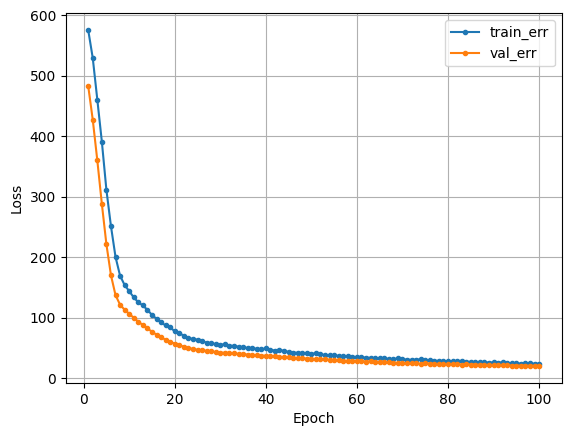

In [ ]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (4) 모델 평가

In [ ]:
loss, pred = evaluate(x_val_ts, y_val_ts, model3, loss_fn, device)

mae = mean_absolute_error(y_val_ts.numpy(), pred.numpy())
mape = mean_absolute_percentage_error(y_val_ts.numpy(), pred.numpy())

print(f'MSE : {loss}')
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MSE : 20.063779830932617
MAE : 3.5012545585632324
MAPE : 0.18422187864780426


## **6.실습1**
* 여러분은 다음의 구조대로 모델링을 수행하고 성능평가를 해 봅시다.
    * 모델 구조
            Sequential(
              (0): Linear(in_features=12, out_features=10, bias=True)
              (1): ReLU()
              (2): Linear(in_features=10, out_features=5, bias=True)
              (3): ReLU()
              (4): Linear(in_features=5, out_features=1, bias=True)
            )
    * epochs(반복횟수) : 100
    * lr(learning rate, 학습률) : 0.01

* 모델 설계

In [ ]:
n_feature = x.shape[1]

model4 = nn.Sequential(
    nn.Linear(n_feature, 10),
    nn.ReLU(),
    nn.Linear(10, 5),
    nn.ReLU(),
    nn.Linear(5, 1)
)

* Loss function과 Optimizer

In [ ]:
loss_fn = nn.MSELoss()
optimizer = Adam(model4.parameters(), lr=0.01)

* 학습

In [ ]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
  train_loss = train(train_loader, model4, loss_fn, optimizer, device)
  val_loss, _ = evaluate(x_val_ts, y_val_ts, model4, loss_fn, device)

  tr_loss_list.append(train_loss)
  val_loss_list.append(val_loss)

  print(f"Epoch {t+1}, train loss : {train_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 607.319092, val loss : 500.117188
Epoch 2, train loss : 519.928589, val loss : 366.345367
Epoch 3, train loss : 329.919006, val loss : 166.216263
Epoch 4, train loss : 174.363739, val loss : 135.727646
Epoch 5, train loss : 148.466446, val loss : 101.224800
Epoch 6, train loss : 122.783539, val loss : 85.569862
Epoch 7, train loss : 105.410156, val loss : 72.723206
Epoch 8, train loss : 87.001015, val loss : 62.408657
Epoch 9, train loss : 77.087868, val loss : 53.131496
Epoch 10, train loss : 66.659691, val loss : 47.745937
Epoch 11, train loss : 61.468449, val loss : 44.927132
Epoch 12, train loss : 57.202682, val loss : 42.664703
Epoch 13, train loss : 53.633396, val loss : 40.593563
Epoch 14, train loss : 51.644760, val loss : 39.797031
Epoch 15, train loss : 49.962429, val loss : 38.273827
Epoch 16, train loss : 47.977669, val loss : 36.488621
Epoch 17, train loss : 45.068501, val loss : 34.799320
Epoch 18, train loss : 43.399616, val loss : 33.907330
Epoch 1

* 학습 곡선

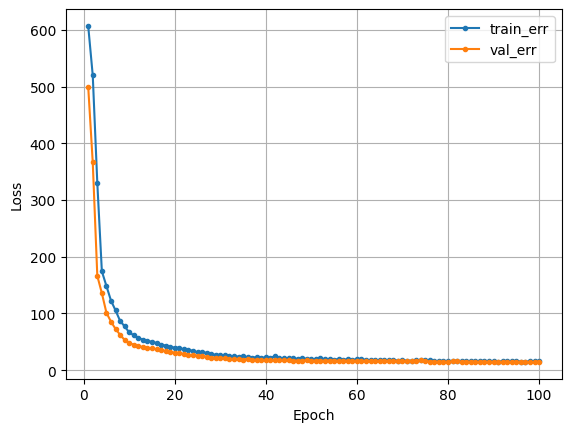

In [ ]:
dl_learning_curve(tr_loss_list, val_loss_list)

* 모델 평가 : MSE

In [ ]:
loss, pred = evaluate(x_val_ts, y_val_ts, model4, loss_fn, device)
mae = mean_absolute_error(y_val_ts.numpy(), pred.numpy())
mape = mean_absolute_percentage_error(y_val_ts.numpy(), pred.numpy())

print(f'MSE : {loss}')
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MSE : 14.972946166992188
MAE : 2.8956613540649414
MAPE : 0.15565559267997742


## **7.실습2**
* 이번에는 여러분이 원하는 구조와 하이퍼파라미터 값을 조정하여 성능을 높여 봅시다.

* 모델 설계

In [45]:
n_feature = x.shape[1]

model5 = nn.Sequential(
    nn.Linear(n_feature, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

* Loss function과 Optimizer

In [46]:
loss_fn = nn.MSELoss()
optimizer = Adam(model5.parameters(), lr=0.01)

* 학습

In [47]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    train_loss = train(train_loader, model5, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model5, loss_fn, device)

    tr_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {train_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 616.227295, val loss : 512.706360
Epoch 2, train loss : 540.190796, val loss : 379.900574
Epoch 3, train loss : 330.560577, val loss : 157.073120
Epoch 4, train loss : 179.257355, val loss : 137.947357
Epoch 5, train loss : 146.034317, val loss : 96.283356
Epoch 6, train loss : 116.966019, val loss : 77.963608
Epoch 7, train loss : 92.958061, val loss : 63.469070
Epoch 8, train loss : 78.727066, val loss : 52.765511
Epoch 9, train loss : 66.619095, val loss : 46.335152
Epoch 10, train loss : 61.025589, val loss : 43.471737
Epoch 11, train loss : 56.279915, val loss : 40.633579
Epoch 12, train loss : 53.052162, val loss : 39.497162
Epoch 13, train loss : 48.784409, val loss : 36.802628
Epoch 14, train loss : 45.739033, val loss : 35.312405
Epoch 15, train loss : 43.692741, val loss : 34.029667
Epoch 16, train loss : 40.422871, val loss : 31.324112
Epoch 17, train loss : 40.343880, val loss : 29.657030
Epoch 18, train loss : 36.493954, val loss : 28.883276
Epoch 19,

* 학습 곡선

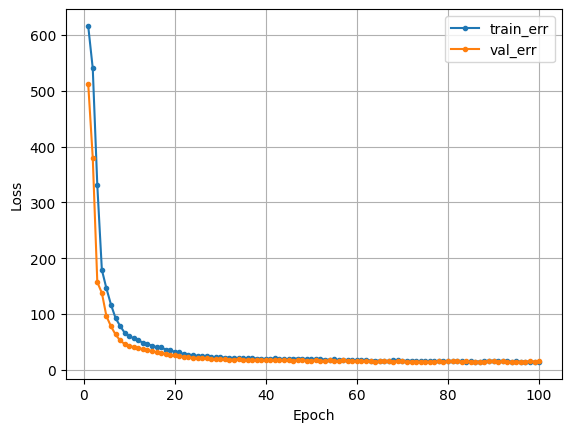

In [48]:
dl_learning_curve(tr_loss_list, val_loss_list)

* 모델 평가 : MSE

In [49]:
loss, pred = evaluate(x_val_ts, y_val_ts, model4, loss_fn, device)
mae = mean_absolute_error(y_val_ts.numpy(), pred.numpy())
mape = mean_absolute_percentage_error(y_val_ts.numpy(), pred.numpy())

print(f'MSE : {loss}')
print(f'MAE : {mae}')
print(f'MAPE : {mape}')

MSE : 14.972946166992188
MAE : 2.8956613540649414
MAPE : 0.15565559267997742
